<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/meachin-learing-project/blob/main/Ridge_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (395, 33)

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

RIDGE REGRESSION RESULTS
MAE      : 1.6391
MSE      : 5.6242
RMSE     : 2.3715
R2 Score : 0.7257


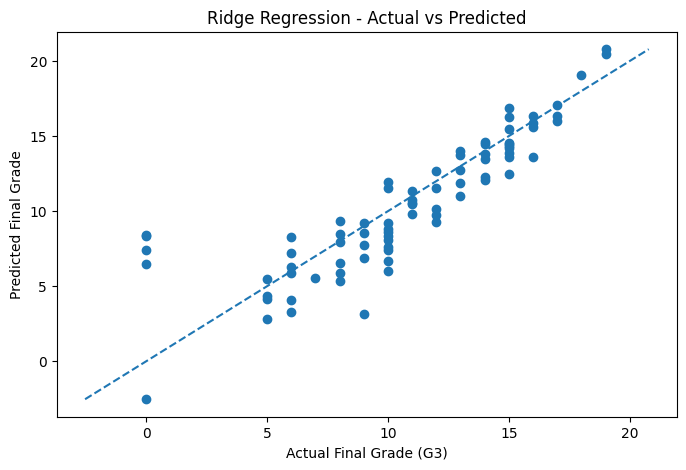

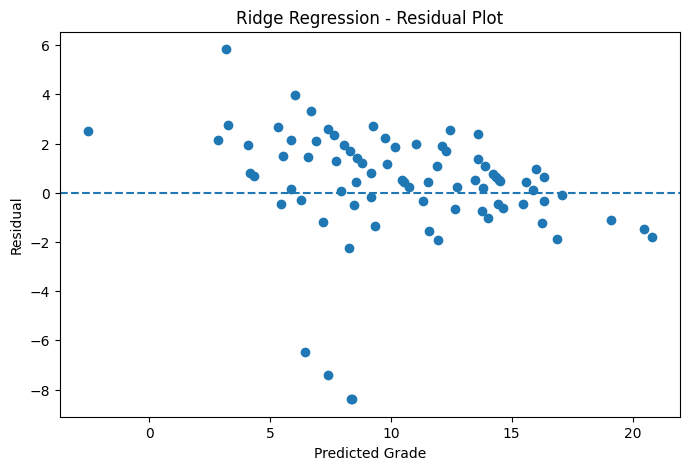

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv("student_data (1).csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ==========================================
# 2. DEFINE INPUT AND TARGET
# ==========================================

# G3 = Final Grade
X = df.drop("G3", axis=1)
y = df["G3"]


# ==========================================
# 3. IDENTIFY COLUMNS
# ==========================================

categorical_columns = X.select_dtypes(
    include=["object"]
).columns

numerical_columns = X.select_dtypes(
    exclude=["object"]
).columns


# ==========================================
# 4. PREPROCESSING
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ]
)


# ==========================================
# 5. RIDGE REGRESSION MODEL
# ==========================================

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "ridge",
        Ridge(alpha=1.0)
    )
])


# ==========================================
# 6. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ==========================================
# 7. TRAIN MODEL
# ==========================================

model.fit(X_train, y_train)


# ==========================================
# 8. PREDICTION
# ==========================================

y_pred = model.predict(X_test)


# ==========================================
# 9. EVALUATION
# ==========================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = mse ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)


print("\n======================================")
print("RIDGE REGRESSION RESULTS")
print("======================================")

print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"R2 Score : {r2:.4f}")


# ==========================================
# 10. ACTUAL VS PREDICTED GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Final Grade (G3)")
plt.ylabel("Predicted Final Grade")
plt.title("Ridge Regression - Actual vs Predicted")

# Perfect prediction line
min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()





# ==========================================
# 12. RESIDUAL GRAPH
# ==========================================

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Grade")
plt.ylabel("Residual")
plt.title("Ridge Regression - Residual Plot")

plt.show()